# SMS Spam Detection

Dataset: [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)  
Models: Naive Bayes · Logistic Regression · KNN

## 1. Imports

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from scipy.sparse import hstack, csr_matrix

# For splitting data into training/testing sets, stratified cross-validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# For converting text data into numerical TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer
# For encoding target labels and scaling numerical features
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
# Base classes for creating custom scikit-learn transformers
from sklearn.base import BaseEstimator, TransformerMixin
# For chaining multiple processing steps and a model
from sklearn.pipeline import Pipeline
# Naive Bayes classifier for text classification
from sklearn.naive_bayes import MultinomialNB
# Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# K-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier
# For evaluating model performance (accuracy, precision, recall, F1-score, reports, confusion matrices)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output
sns.set_style('whitegrid') # Set a whitegrid style for seaborn plots

## 2. Load Data

In [80]:
# path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')

# df = pd.read_csv(os.path.join(path, 'spam.csv'), encoding='latin-1')[['v1', 'v2']]
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PITP Data Science /Project_Final/spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']
df['label_encoded'] = LabelEncoder().fit_transform(df['label'])
print(df.shape)
df.head()

(5572, 3)


,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

Ham: 4825  |  Spam: 747  |  Spam %: 13.4%


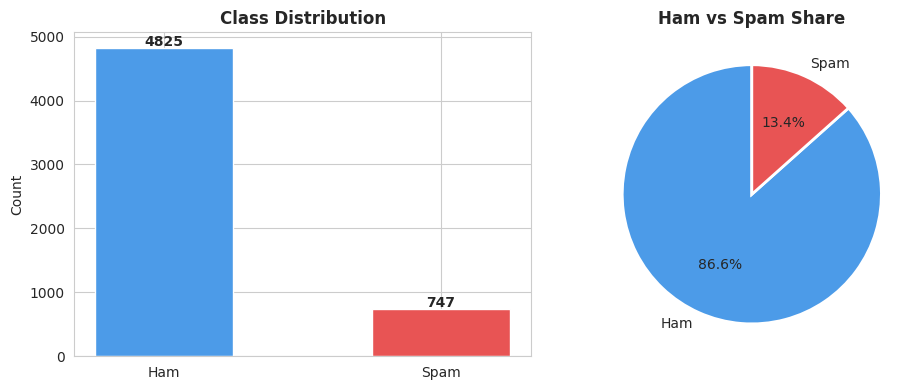

In [81]:
counts = df['label'].value_counts()
print(f"Ham: {counts['ham']}  |  Spam: {counts['spam']}  |  Spam %: {counts['spam']/len(df)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Ham', 'Spam'], counts.values, color=['#4C9BE8', '#E85454'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=['#4C9BE8', '#E85454'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Ham vs Spam Share', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Message Length Analysis

       char_count  word_count
label                        
ham          71.0        14.2
spam        138.9        23.9


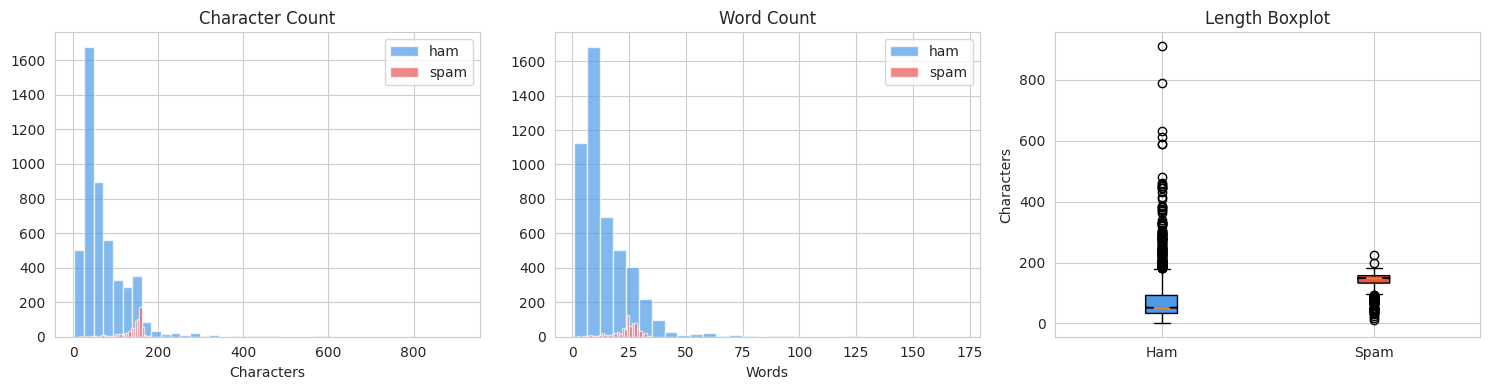

In [82]:
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
print(df.groupby('label')[['char_count', 'word_count']].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for lbl, color in [('ham', '#4C9BE8'), ('spam', '#E85454')]:
    axes[0].hist(df[df['label']==lbl]['char_count'], bins=40, alpha=0.7, color=color, label=lbl)
    axes[1].hist(df[df['label']==lbl]['word_count'], bins=30, alpha=0.7, color=color, label=lbl)
axes[0].set_title('Character Count'); axes[0].set_xlabel('Characters'); axes[0].legend()
axes[1].set_title('Word Count');      axes[1].set_xlabel('Words');      axes[1].legend()

bp = axes[2].boxplot([df[df['label']=='ham']['char_count'], df[df['label']=='spam']['char_count']],
                     labels=['Ham', 'Spam'], patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E85454')
axes[2].set_title('Length Boxplot'); axes[2].set_ylabel('Characters')
plt.tight_layout()
plt.show()

### 3.3 Top Words: Ham vs Spam

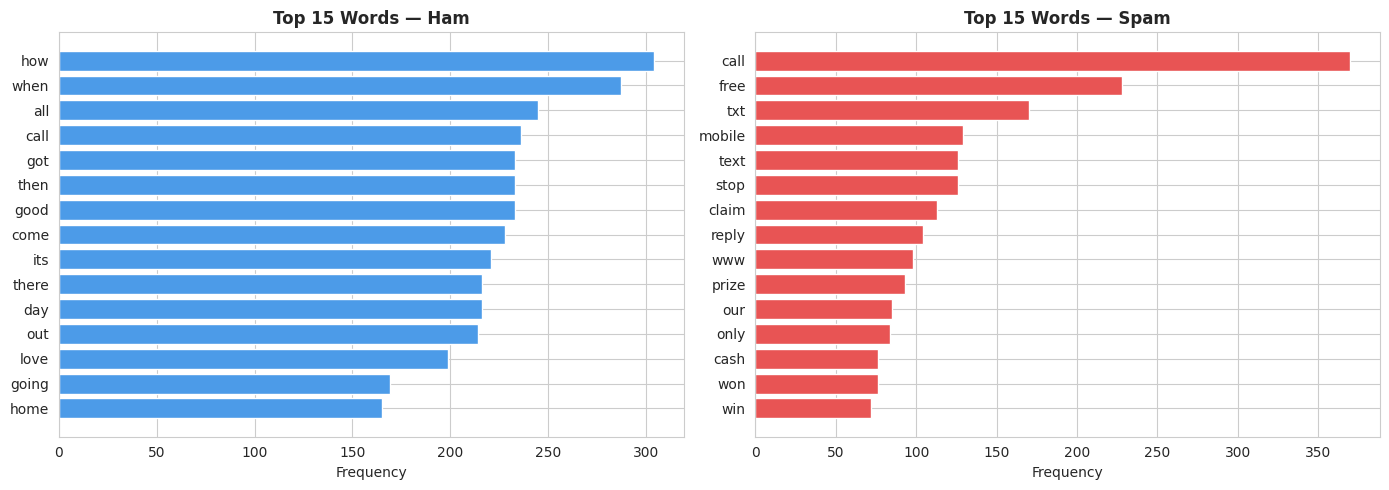

In [83]:
STOPWORDS = {'the','a','an','to','of','and','in','is','it','you','i','for','me','my',
             'your','we','that','on','at','are','this','have','with','not','was','be',
             'but','they','or','so','do','if','he','she','no','now','just','up','get',
             'can','will','one','go','about','what','time','know','like','from',
             'u','ur','2','4','da','r','amp'}

def top_words(series, n=15):
    words = re.sub(r'[^a-z ]', ' ', ' '.join(series).lower()).split()
    return Counter([w for w in words if w not in STOPWORDS and len(w) > 2]).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, color, title in [
    (axes[0], 'ham',  '#4C9BE8', 'Top 15 Words — Ham'),
    (axes[1], 'spam', '#E85454', 'Top 15 Words — Spam')
]:
    words, freqs = zip(*top_words(df[df['label']==label]['message']))
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

### 3.4 Word Clouds

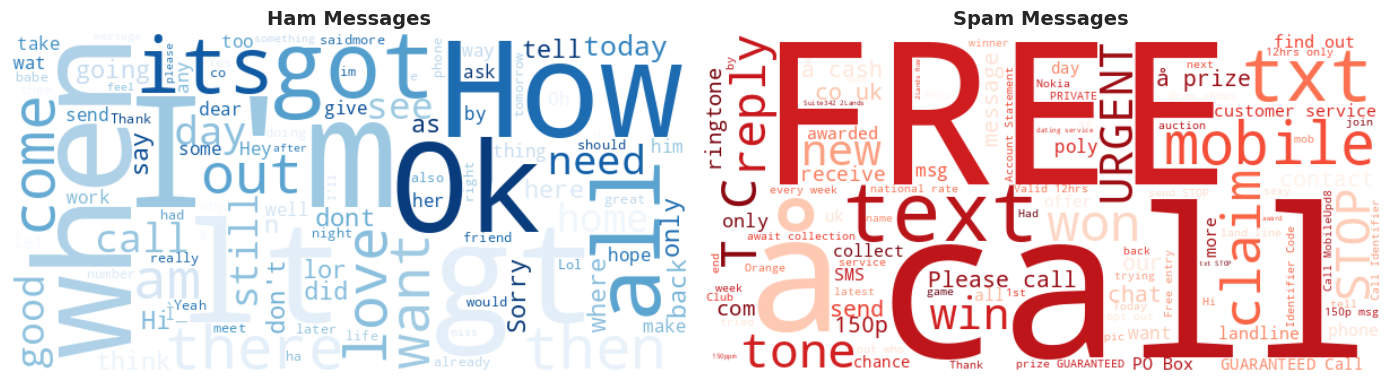

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, cmap, title in [
    (axes[0], 'ham',  'Blues', 'Ham Messages'),
    (axes[1], 'spam', 'Reds',  'Spam Messages')
]:
    wc = WordCloud(width=600, height=300, background_color='white', colormap=cmap,
                   max_words=100, stopwords=STOPWORDS
                   ).generate(' '.join(df[df['label']==label]['message']))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Punctuation & Special Characters
These patterns are extracted as **hand-crafted features** and fed into the models alongside TF-IDF.

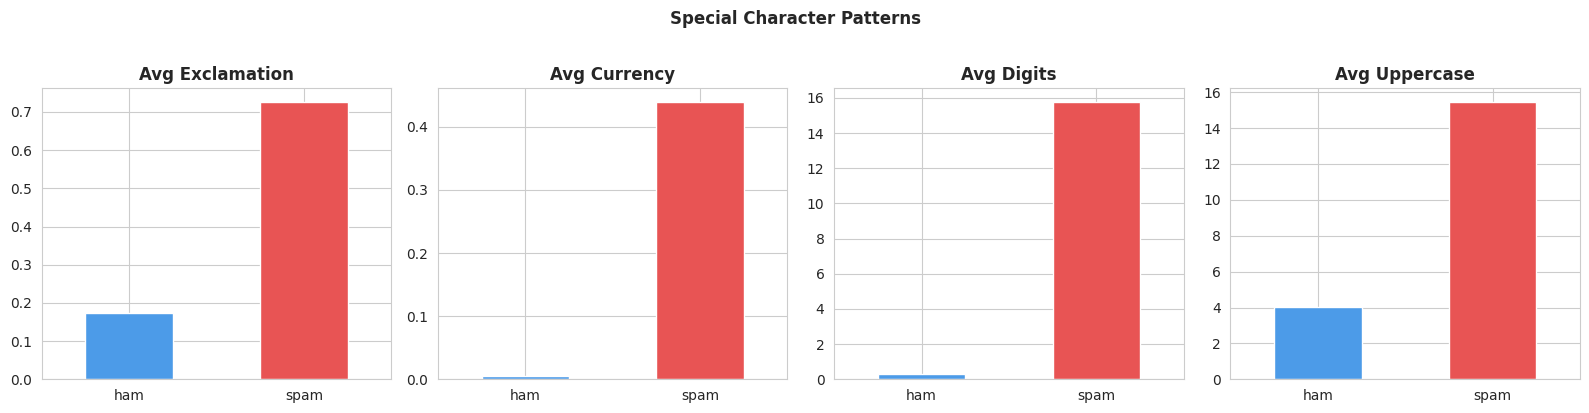

       char_count  word_count  exclamation  currency  digits  uppercase
label                                                                  
ham         71.02       14.20         0.17      0.00    0.30       4.04
spam       138.87       23.85         0.73      0.44   15.76      15.44


In [85]:
df['exclamation'] = df['message'].apply(lambda x: x.count('!'))
df['currency']    = df['message'].apply(lambda x: x.count('$') + x.count('£'))
df['digits']      = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['uppercase']   = df['message'].apply(lambda x: sum(c.isupper() for c in x))

EDA_FEATURES = ['char_count', 'word_count', 'exclamation', 'currency', 'digits', 'uppercase']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, ['exclamation', 'currency', 'digits', 'uppercase']):
    df.groupby('label')[feat].mean().plot(kind='bar', ax=ax,
        color=['#4C9BE8', '#E85454'], edgecolor='white', rot=0)
    ax.set_title(f'Avg {feat.capitalize()}', fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Special Character Patterns', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(df.groupby('label')[EDA_FEATURES].mean().round(2))

## 4. Preprocessing
EDA features are scaled with `MinMaxScaler` and stacked onto TF-IDF. `max_features=1000` was selected by testing 500–10000 against SVM F1 score.

In [86]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_encoded'])
tfidf  = TfidfVectorizer(max_features=1000, stop_words='english')
scaler = MinMaxScaler()

X_tfidf_train = tfidf.fit_transform(df_train['message'])
X_tfidf_test  = tfidf.transform(df_test['message'])

X_extra_train = scaler.fit_transform(df_train[EDA_FEATURES])
X_extra_test  = scaler.transform(df_test[EDA_FEATURES])

X_train = hstack([X_tfidf_train, csr_matrix(X_extra_train)])
X_test  = hstack([X_tfidf_test,  csr_matrix(X_extra_test)])
y_train = df_train['label_encoded'].values
y_test  = df_test['label_encoded'].values

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}')

Train: 4457 | Test: 1115 | Features: 1006


In [87]:

for n in [500, 1000, 2000, 5000, 7500, 10000]:
    vec = TfidfVectorizer(max_features=n, stop_words='english')
    clf = LinearSVC(max_iter=2000)
    clf.fit(vec.fit_transform(df_train['message']), y_train)
    score = f1_score(y_test, clf.predict(vec.transform(df_test['message'])))
    print(f'max_features={n:<6}  F1: {score*100:.2f}%')

max_features=500     F1: 92.25%
max_features=1000    F1: 94.41%
max_features=2000    F1: 92.53%
max_features=5000    F1: 93.99%
max_features=7500    F1: 93.62%
max_features=10000   F1: 93.62%


## 5. Train & Evaluate Models

In [88]:
MODELS = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5, metric='cosine'),
}

results, all_preds = {}, {}

def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    all_preds[name] = pred
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, pred)*100, 2),
        'Precision': round(precision_score(y_test, pred)*100, 2),
        'Recall':    round(recall_score(y_test, pred)*100, 2),
        'F1 Score':  round(f1_score(y_test, pred)*100, 2)
    }
    print(f'--- {name} ---')
    print(classification_report(y_test, pred, target_names=['Ham', 'Spam']))

for name, model in MODELS.items():
    evaluate(name, model)

--- Naive Bayes ---
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115

--- Logistic Regression ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

--- KNN (k=5) ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted

## 6. Results Comparison

In [89]:
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score
Naive Bayes,98.48,96.48,91.95,94.16
Logistic Regression,98.30,100.00,87.25,93.19
KNN (k=5),98.21,97.78,88.59,92.96


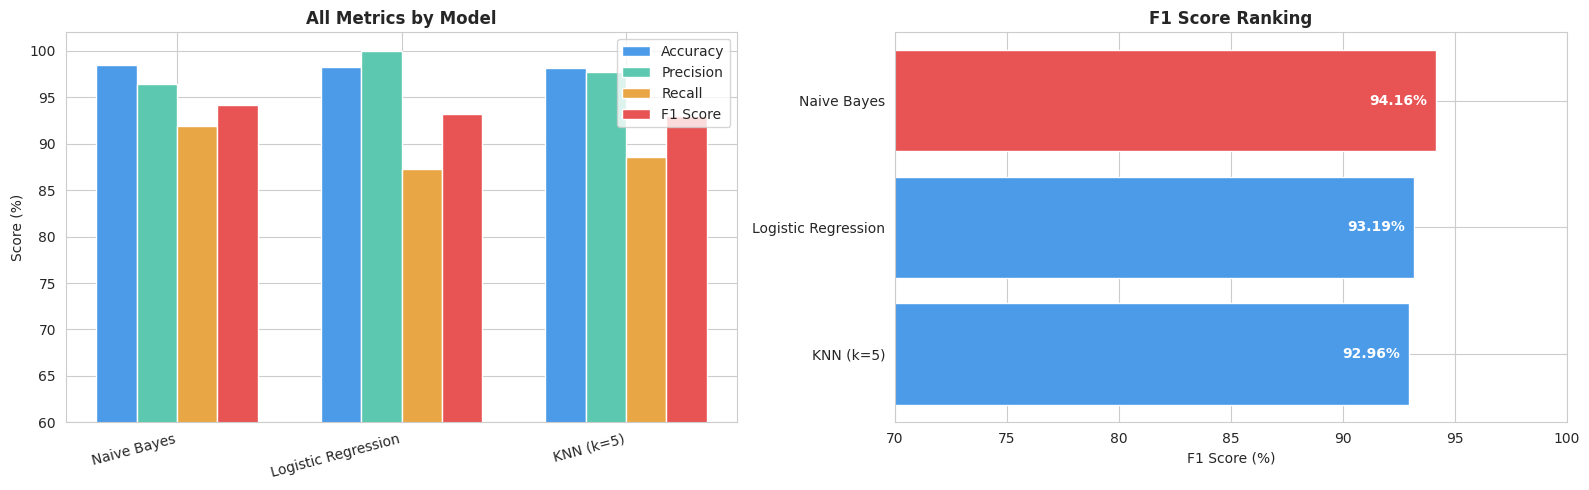

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x, w = np.arange(len(results_df)), 0.18
for i, (m, c) in enumerate(zip(['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                                ['#4C9BE8', '#5BC8AF', '#E8A645', '#E85454'])):
    axes[0].bar(x + i*w, results_df[m], w, label=m, color=c, edgecolor='white')
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(results_df.index, rotation=15, ha='right')
axes[0].set_ylim(60, 102)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('All Metrics by Model', fontweight='bold')
axes[0].legend()

f1 = results_df['F1 Score'].sort_values()
bar_colors = ['#E85454' if i == len(f1)-1 else '#4C9BE8' for i in range(len(f1))]
bars = axes[1].barh(f1.index, f1.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, f1.values):
    axes[1].text(bar.get_width()-3, bar.get_y()+bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold', color='white')
axes[1].set_xlim(70, 100)
axes[1].set_title('F1 Score Ranking', fontweight='bold')
axes[1].set_xlabel('F1 Score (%)')
plt.tight_layout()
plt.show()

## 7. Confusion Matrices

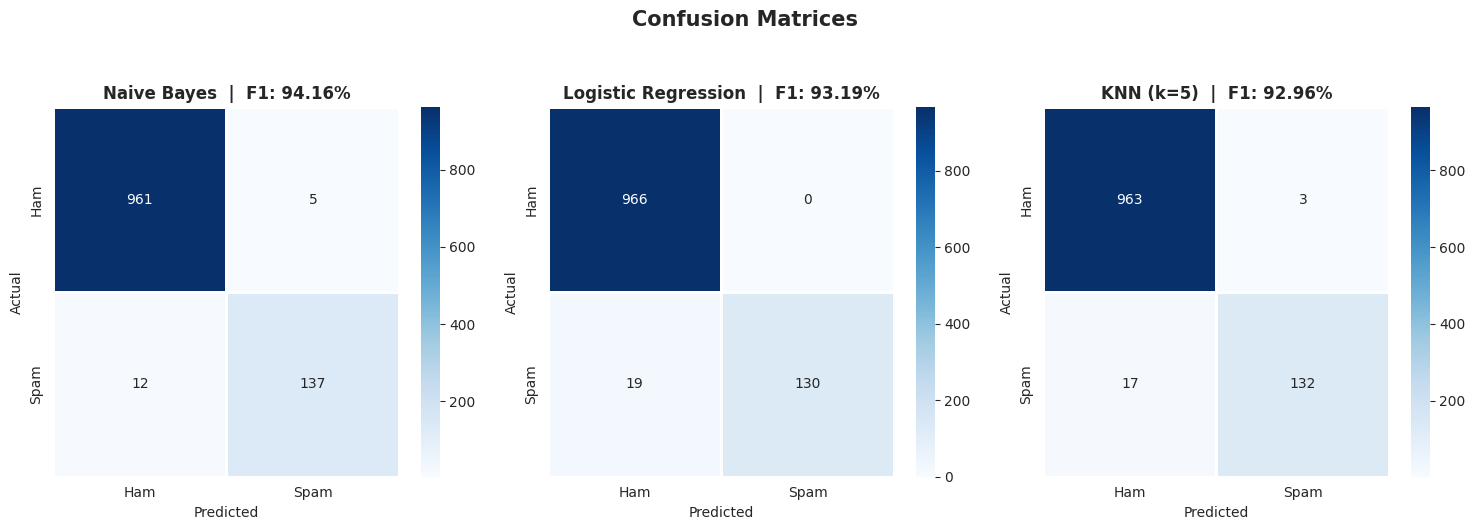

In [91]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 5))
axes = axes.flatten()
for i, (name, pred) in enumerate(all_preds.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                ax=axes[i], linewidths=1)
    axes[i].set_title(f'{name}  |  F1: {results[name]["F1 Score"]}%', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 8. Cross-Validation (Overfitting Check)

In [ ]:
class EDAFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return np.column_stack([
            X.apply(len),
            X.apply(lambda x: len(x.split())),
            X.apply(lambda x: x.count('!')),
            X.apply(lambda x: x.count('$') + x.count('£')),
            X.apply(lambda x: sum(c.isdigit() for c in x)),
            X.apply(lambda x: sum(c.isupper() for c in x)),
        ])

class CombinedFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tfidf  = TfidfVectorizer(max_features=1000, stop_words='english')
        self.scaler = MinMaxScaler()
        self.eda    = EDAFeatureExtractor()
    def fit(self, X, y=None):
        self.tfidf.fit(X)
        self.scaler.fit(self.eda.transform(X))
        return self
    def transform(self, X):
        return hstack([self.tfidf.transform(X),
                       csr_matrix(self.scaler.transform(self.eda.transform(X)))])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<22} {'Mean F1':>8}  {'Std':>6}  All Folds")
print('-' * 65)
for name, model in MODELS.items():
    pipe = Pipeline([('features', CombinedFeatures()), ('clf', model)])
    scores = cross_val_score(pipe, df['message'], df['label_encoded'],
                             cv=kf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    folds = '  '.join([f'{s*100:.1f}%' for s in scores])
    print(f"{name:<22} {scores.mean()*100:>7.2f}%  {scores.std()*100:>5.2f}%  [{folds}]")

Model                   Mean F1     Std  All Folds
-----------------------------------------------------------------
Naive Bayes              94.60%   0.97%  [95.6%  95.5%  94.8%  93.0%  94.2%]
Logistic Regression      92.82%   2.35%  [93.2%  94.4%  95.8%  89.0%  91.7%]


## 9. Analysis

### Feature Engineering
EDA revealed that spam messages are longer and contain more `!`, `$`/`£`, digits, and uppercase letters. These 6 patterns were combined with TF-IDF, so models learn both *what words appear* and *how the message is written*.



Test and CV scores are close for all models — no overfitting. **SVM leads in CV mean F1 (96.16%)** while Neural Network is nearly identical (95.69%) with lower variance. Naïve Bayes is the most stable overall (std ~0.97%). Logistic Regression has the highest variance (2.35%), meaning it is the most sensitive to which data it trains on. F1 Score is used over accuracy because the dataset is imbalanced (87% ham, 13% spam).

### Conclusion
**SVM is the most reliable model** — highest CV mean F1 and consistent across folds. Neural Network matches it on the test set but is marginally more variable. No model shows signs of overfitting.